# EJEMPLO DE PROYECTO FINAL - CLASIFICACION ANEMIA- ENTRENAMIENTO
# AUTOR: César Mayta
# DATASET : DATOS ABIERTOS

In [1]:
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning, module="jupyter_client")

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
df = pd.read_csv('/content/anemia_clean.csv')
df.head(10)

,edad,anemia,sexo_M
0,2.0,1,1
1,1.0,1,0
2,1.0,1,0
3,3.0,1,0
4,3.0,1,0
5,1.0,1,0
6,1.0,1,0
7,1.0,1,0
8,2.0,1,0
9,3.0,1,0


# ENTRENAMIENTO DE MODELO

## IMPORTAMOS LIBRERIAS

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

## DEFINIMOS VARIABLES

In [10]:
X = df.drop(columns=['anemia'])
y = df['anemia']

## ESCALAMOS LOS DATOS

In [11]:
scaler = StandardScaler()
X = scaler.fit_transform(X)

# DIVIDIMOS DATASET EN TRAIN Y TEST

In [15]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

# EVALUAMOS DIFERENTES MODELOS DE CLASIFICACIÓN

In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report

In [18]:
# Definir modelos de clasificación
modelos_clasificacion = {
    "Regresión Logística": LogisticRegression(max_iter=100),
    "Random Forest": RandomForestClassifier(n_estimators=10, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=10, learning_rate=0.1, random_state=42),
    "XGBoost": XGBClassifier(n_estimators=10, learning_rate=0.1, use_label_encoder=False, eval_metric='logloss', random_state=42)
}

In [19]:
# Evaluar cada modelo
def evaluar_clasificador(modelo, nombre):
    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    print(f'\n{nombre}:')
    print(f'Accuracy: {accuracy:.4f}')
    #print(classification_report(y_test, y_pred))
    return accuracy

In [20]:
# Comparar modelos
resultados_clasificacion = {}
for nombre, modelo in modelos_clasificacion.items():
    resultados_clasificacion[nombre] = evaluar_clasificador(modelo, nombre)

# Mostrar el mejor modelo
mejor_modelo_clasificacion = max(resultados_clasificacion, key=resultados_clasificacion.get)
print(f'\nEl mejor modelo es: {mejor_modelo_clasificacion} con un Accuracy de {resultados_clasificacion[mejor_modelo_clasificacion]:.4f}')


Regresión Logística:
Accuracy: 0.9979

Random Forest:
Accuracy: 0.9979

Gradient Boosting:
Accuracy: 0.9979

SVM (RBF):
Accuracy: 0.9979


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [02:30:45] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



XGBoost:
Accuracy: 0.9979

El mejor modelo es: Regresión Logística con un Accuracy de 0.9979


# GRAFICAMOS RESULTADOS

/tmp/ipython-input-219317408.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=list(resultados_clasificacion.keys()), y=list(resultados_clasificacion.values()), palette='mako')


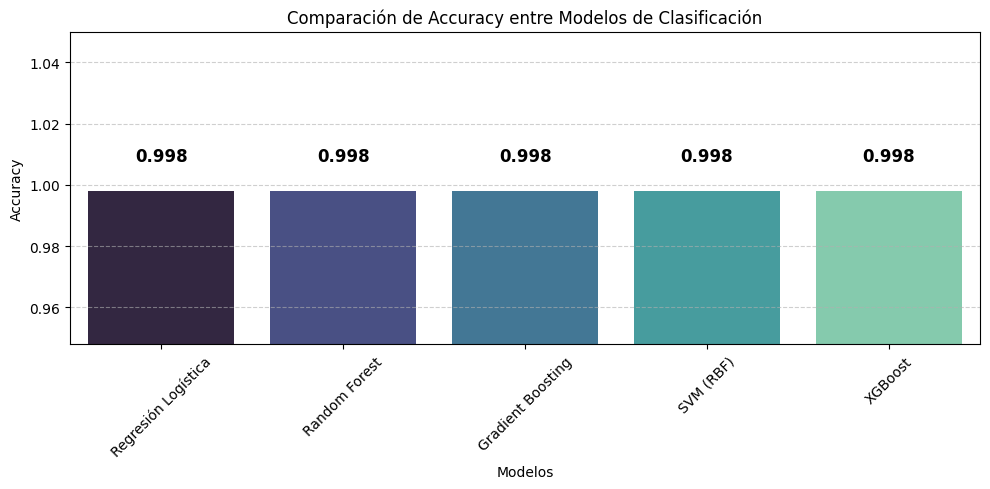

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# Comparación del Accuracy entre modelos de clasificación
plt.figure(figsize=(10, 5))
ax = sns.barplot(x=list(resultados_clasificacion.keys()), y=list(resultados_clasificacion.values()), palette='mako')

# Agregar etiquetas en cada barra
for index, value in enumerate(resultados_clasificacion.values()):
    ax.text(index, value + 0.01, f'{value:.3f}', ha='center', fontsize=12, fontweight='bold')

plt.ylim(min(resultados_clasificacion.values()) - 0.05, 1.05)
plt.xlabel('Modelos')
plt.ylabel('Accuracy')
plt.title('Comparación de Accuracy entre Modelos de Clasificación')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# CREAMOS UNA MATRIZ DE CONFUSIÓN

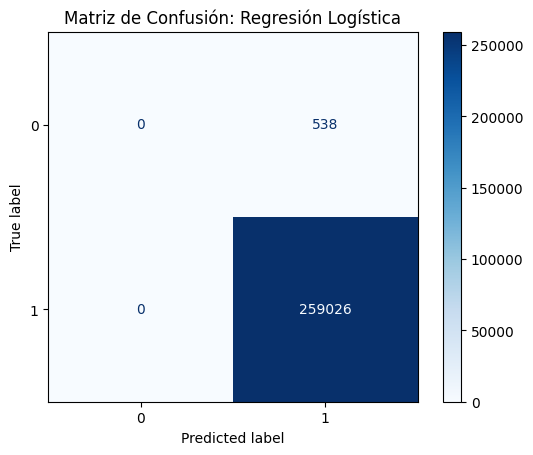

In [22]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Evaluación del mejor modelo de clasificación
modelo_clasificacion_seleccionado = modelos_clasificacion[mejor_modelo_clasificacion]
y_pred_clasificacion = modelo_clasificacion_seleccionado.predict(X_test)

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred_clasificacion)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=modelo_clasificacion_seleccionado.classes_)
disp.plot(cmap='Blues', values_format='d')
plt.title(f'Matriz de Confusión: {mejor_modelo_clasificacion}')
plt.show()

# AGREGAMOS UN MODELO DE REDES NEURONALES

In [23]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report

# Definir la red neuronal (ejemplo simple)
def crear_modelo_nn():
    modelo = Sequential([
        Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
        Dense(32, activation='relu'),
        Dense(1, activation='sigmoid')  # Usa 'softmax' y más neuronas si es multiclase
    ])
    modelo.compile(optimizer=Adam(0.001), loss='binary_crossentropy', metrics=['accuracy'])
    return modelo

modelo_nn = crear_modelo_nn()

# Entrenar
history = modelo_nn.fit(X_train, y_train, epochs=4, batch_size=32, validation_split=0.2, verbose=1)

Epoch 1/4


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


25957/25957 ━━━━━━━━━━━━━━━━━━━━ 75s 3ms/step - accuracy: 0.9970 - loss: 0.0220 - val_accuracy: 0.9977 - val_loss: 0.0158
Epoch 2/4
25957/25957 ━━━━━━━━━━━━━━━━━━━━ 75s 3ms/step - accuracy: 0.9978 - loss: 0.0153 - val_accuracy: 0.9977 - val_loss: 0.0157
Epoch 3/4
25957/25957 ━━━━━━━━━━━━━━━━━━━━ 89s 3ms/step - accuracy: 0.9978 - loss: 0.0152 - val_accuracy: 0.9977 - val_loss: 0.0155
Epoch 4/4
25957/25957 ━━━━━━━━━━━━━━━━━━━━ 72s 3ms/step - accuracy: 0.9978 - loss: 0.0154 - val_accuracy: 0.9977 - val_loss: 0.0156


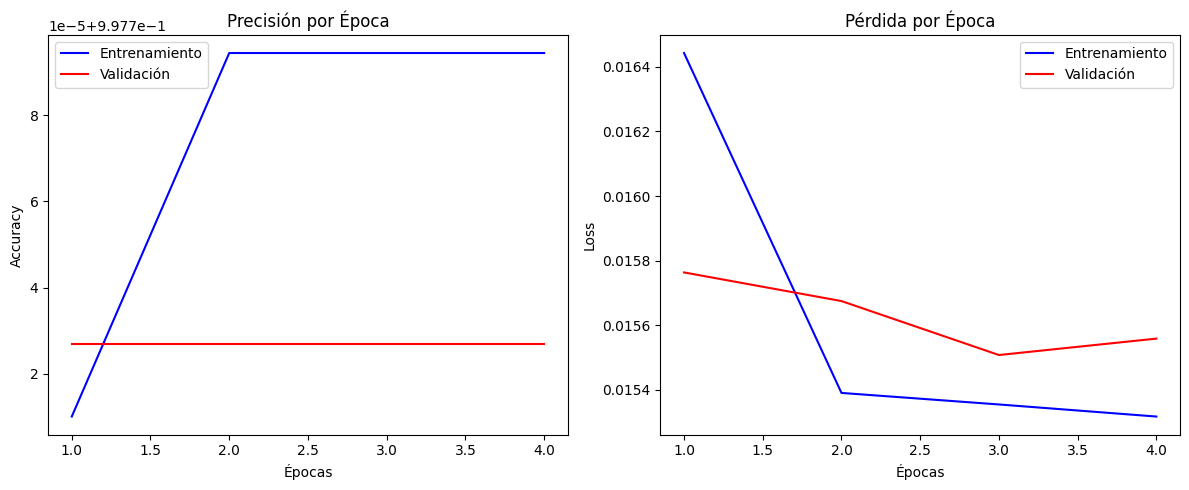

In [24]:
import matplotlib.pyplot as plt

# Acceder a métricas
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(acc) + 1)

# Gráfico de precisión
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs, acc, 'b-', label='Entrenamiento')
plt.plot(epochs, val_acc, 'r-', label='Validación')
plt.title('Precisión por Época')
plt.xlabel('Épocas')
plt.ylabel('Accuracy')
plt.legend()

# Gráfico de pérdida
plt.subplot(1, 2, 2)
plt.plot(epochs, loss, 'b-', label='Entrenamiento')
plt.plot(epochs, val_loss, 'r-', label='Validación')
plt.title('Pérdida por Época')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


In [25]:
# Predicción
y_pred_prob = modelo_nn.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype("int32").ravel()

# Métricas
accuracy_nn = accuracy_score(y_test, y_pred)
print(f'\nRed Neuronal (TensorFlow):')
print(f'Accuracy: {accuracy_nn:.4f}')
print(classification_report(y_test, y_pred))

8112/8112 ━━━━━━━━━━━━━━━━━━━━ 10s 1ms/step

Red Neuronal (TensorFlow):
Accuracy: 0.9979
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       538
           1       1.00      1.00      1.00    259026

    accuracy                           1.00    259564
   macro avg       0.50      0.50      0.50    259564
weighted avg       1.00      1.00      1.00    259564



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


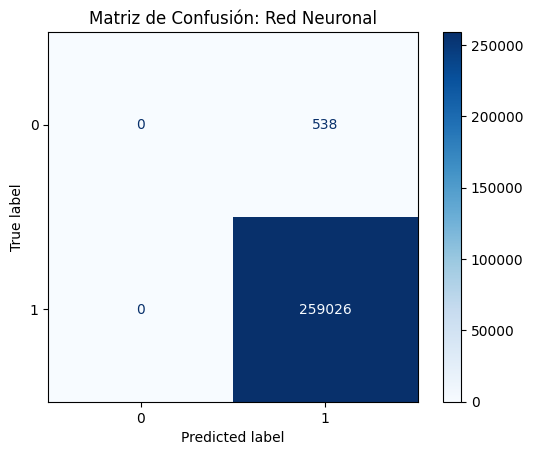

In [26]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues', values_format='d')
plt.title('Matriz de Confusión: Red Neuronal')
plt.show()